# Differential expression: TB at diagnosis vs healthy controls

Finds genes whose blood expression differs between **TB patients at diagnosis** and **healthy controls** in SRP092402.

**Method.** The refine.bio tutorial uses DESeq2, which models raw read counts. This matrix is already normalized (tximport + quantile normalization, most values below 1), so rounding it to fake counts would turn most of it into zeros. Instead we use the standard approach for normalized, log-scale data:

- log2(expression + 1)
- Welch's t-test per gene (doesn't assume equal variance between groups)
- Benjamini-Hochberg correction for testing thousands of genes at once (adjusted p-value = false discovery rate)

Requires `data/SRP092402/SRP092402_Symbols.tsv` from `gene_id_annotation.R`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text
from scipy import stats

data_dir = Path("../data/SRP092402")
results_dir = Path(".")  # notebooks live in results/, next to their outputs

# Significance thresholds
PADJ_CUTOFF = 0.05
# |log2 fold change| >= 0.5 means at least a ~1.4-fold difference. The usual cutoff of 1 (2-fold)
# is too strict here: quantile normalization compresses fold changes, and only 14 genes pass it.
LFC_CUTOFF = 0.5

## Load data and pick the two groups

In [2]:
expression_df = pd.read_csv(data_dir / "SRP092402_Symbols.tsv", sep="\t", index_col="Ensembl")
expression_mat = expression_df.drop(columns=["first_mapped_symbol", "all_symbols"])
metadata = pd.read_csv(data_dir / "metadata_SRP092402.tsv", sep="\t")

group_labels = {"tb subjects": "TB", "healthy controls": "Healthy"}
selected = metadata[
    metadata["refinebio_disease"].isin(group_labels)
    & (metadata["refinebio_time"] == "dx")
].copy()
selected["group"] = selected["refinebio_disease"].map(group_labels)
selected["group"].value_counts()

group
TB         181
Healthy     50
Name: count, dtype: int64

## Merge technical replicates

Average the lane replicates of each blood sample so every biological sample counts once (same as `S2. PCA, t-SNE, UMAP.ipynb`).

In [3]:
log_mat = np.log2(expression_mat[selected["refinebio_accession_code"]] + 1)

selected["sample_id"] = "S" + selected["refinebio_subject"].astype(str) + "_" + selected["refinebio_time"]
run_to_sample = selected.set_index("refinebio_accession_code")["sample_id"]

sample_mat = log_mat.T.groupby(run_to_sample).mean().T
sample_group = selected.drop_duplicates("sample_id").set_index("sample_id").loc[sample_mat.columns, "group"]
sample_group.value_counts()

group
TB         91
Healthy    21
Name: count, dtype: int64

## Filter out unexpressed genes

Keep genes with median log2 expression of at least 1 in **either** group, so genes switched on in only one group are kept.

In [4]:
tb = sample_mat.loc[:, sample_group == "TB"]
healthy = sample_mat.loc[:, sample_group == "Healthy"]

expressed = (tb.median(axis=1) >= 1) | (healthy.median(axis=1) >= 1)
tb, healthy = tb[expressed], healthy[expressed]
print(f"Testing {expressed.sum():,} of {len(expressed):,} genes")

Testing 18,676 of 43,363 genes


## Test every gene

In [5]:
t_stat, pvalue = stats.ttest_ind(tb, healthy, axis=1, equal_var=False)

results = pd.DataFrame({
    "symbol": expression_df.loc[tb.index, "first_mapped_symbol"],
    "mean_TB": tb.mean(axis=1),
    "mean_Healthy": healthy.mean(axis=1),
    "log2FoldChange": tb.mean(axis=1) - healthy.mean(axis=1),
    "t_statistic": t_stat,
    "pvalue": pvalue,
    "padj": stats.false_discovery_control(pvalue, method="bh"),
}, index=tb.index)
results.index.name = "Ensembl"

results["direction"] = "Not significant"
significant = (results["padj"] < PADJ_CUTOFF) & (results["log2FoldChange"].abs() >= LFC_CUTOFF)
results.loc[significant & (results["log2FoldChange"] > 0), "direction"] = "Higher in TB"
results.loc[significant & (results["log2FoldChange"] < 0), "direction"] = "Lower in TB"

results = results.sort_values("padj")
results.to_csv(results_dir / "diff_expr_tb_vs_healthy.tsv", sep="\t")

print(f"padj < {PADJ_CUTOFF}: {(results['padj'] < PADJ_CUTOFF).sum():,} genes")
print(f"padj < {PADJ_CUTOFF} and |log2FC| >= {LFC_CUTOFF}:")
results["direction"].value_counts()

padj < 0.05: 10,369 genes
padj < 0.05 and |log2FC| >= 0.5:


direction
Not significant    18427
Higher in TB         172
Lower in TB           77
Name: count, dtype: int64

## Volcano plot

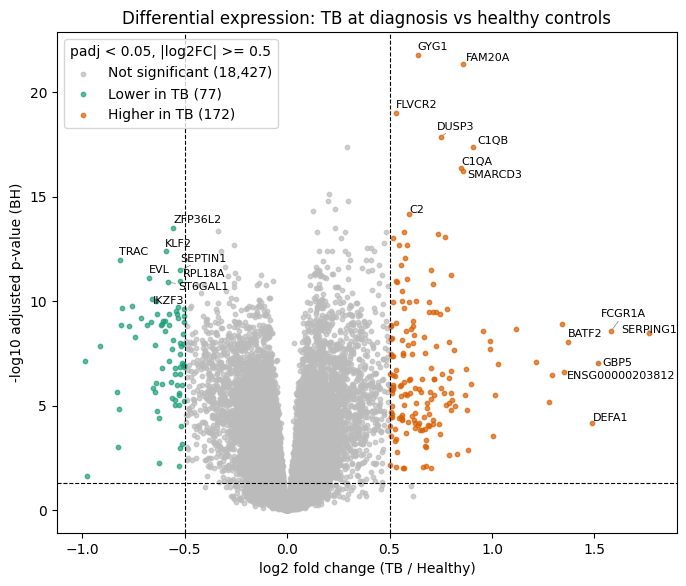

In [6]:
colors = {"Higher in TB": "#d95f02", "Lower in TB": "#1b9e77", "Not significant": "#bbbbbb"}
results["neg_log10_padj"] = -np.log10(results["padj"])

fig, ax = plt.subplots(figsize=(8, 6.5))
for direction in ["Not significant", "Lower in TB", "Higher in TB"]:
    subset = results[results["direction"] == direction]
    ax.scatter(
        subset["log2FoldChange"], subset["neg_log10_padj"],
        s=10, alpha=0.7, color=colors[direction], label=f"{direction} ({len(subset):,})",
    )

ax.axhline(-np.log10(PADJ_CUTOFF), color="black", linestyle="--", linewidth=0.8)
for x in (-LFC_CUTOFF, LFC_CUTOFF):
    ax.axvline(x, color="black", linestyle="--", linewidth=0.8)

# Label the most significant genes on each side, plus the largest fold changes
sig = results[results["direction"] != "Not significant"]
to_label = pd.concat([
    sig[sig["direction"] == "Higher in TB"].head(8),
    sig[sig["direction"] == "Lower in TB"].head(8),
    sig.reindex(sig["log2FoldChange"].abs().nlargest(6).index),
]).drop_duplicates()
texts = [
    ax.text(row["log2FoldChange"], row["neg_log10_padj"],
            row["symbol"] if pd.notna(row["symbol"]) else ensembl, fontsize=8)
    for ensembl, row in to_label.iterrows()
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set(
    title="Differential expression: TB at diagnosis vs healthy controls",
    xlabel="log2 fold change (TB / Healthy)",
    ylabel="-log10 adjusted p-value (BH)",
)
ax.legend(title=f"padj < {PADJ_CUTOFF}, |log2FC| >= {LFC_CUTOFF}", loc="upper left")
fig.savefig(results_dir / "S3. Volcano Graph.png", dpi=150, bbox_inches="tight")
plt.show()

## Top 50 differentially expressed genes

Ranked by adjusted p-value among genes passing both cutoffs.

In [7]:
top50 = (
    results[results["direction"] != "Not significant"]
    .head(50)
    .reset_index()
    [["Ensembl", "symbol", "log2FoldChange", "mean_TB", "mean_Healthy", "pvalue", "padj", "direction"]]
)
top50.index = range(1, len(top50) + 1)
top50.to_csv(results_dir / "S3. Top 50 Differentially Expressed Genes.tsv", sep="\t", index_label="rank")

formatted = top50.assign(
    log2FoldChange=top50["log2FoldChange"].round(2),
    mean_TB=top50["mean_TB"].round(2),
    mean_Healthy=top50["mean_Healthy"].round(2),
    pvalue=top50["pvalue"].map("{:.2e}".format),
    padj=top50["padj"].map("{:.2e}".format),
)
(results_dir / "S3. Top 50 Differentially Expressed Genes.md").write_text(formatted.rename_axis("Rank").reset_index().to_markdown(index=False), encoding="utf-8")
formatted

,Ensembl,symbol,log2FoldChange,mean_TB,mean_Healthy,pvalue,padj,direction
1,ENSG00000163754,GYG1,0.64,3.59,2.95,8.87e-27,1.66e-22,Higher in TB
2,ENSG00000108950,FAM20A,0.86,2.18,1.32,4.65e-26,4.34e-22,Higher in TB
3,ENSG00000119686,FLVCR2,0.53,2.49,1.96,1.66e-23,1.03e-19,Higher in TB
4,ENSG00000108861,DUSP3,0.75,3.48,2.73,2.94e-22,1.37e-18,Higher in TB
5,ENSG00000173369,C1QB,0.91,2.59,1.68,1.08e-21,3.99e-18,Higher in TB
6,ENSG00000173372,C1QA,0.85,2.67,1.82,1.63e-20,4.34e-17,Higher in TB
7,ENSG00000082014,SMARCD3,0.86,3.50,2.64,2.46e-20,5.74e-17,Higher in TB
8,ENSG00000166278,C2,0.60,2.31,1.71,5.08e-18,6.77e-15,Higher in TB
9,ENSG00000152518,ZFP36L2,-0.56,4.63,5.19,2.55e-17,3.17e-14,Lower in TB
10,ENSG00000136861,CDK5RAP2,0.57,3.19,2.62,5.73e-17,5.10e-14,Higher in TB


## Summary

**Setup:** 91 TB patients at diagnosis vs 21 healthy controls (technical replicates averaged), 18,676 expressed genes, Welch's t-test with Benjamini-Hochberg correction.

**How many genes differ**
- 10,369 genes have padj < 0.05. With 112 samples the test has enough power to detect very small differences, so significance alone isn't very informative here; the fold-change cutoff does the real filtering.
- **249 genes** pass padj < 0.05 and |log2FC| >= 0.5 (at least ~1.4-fold): **172 higher in TB** and **77 lower in TB**.
- Fold changes are small overall (largest: SERPING1, +1.76, about 3.4-fold). Quantile normalization compresses fold changes, which is why only 14 genes pass the usual 2-fold cutoff.

**Higher in TB: innate immune activation**
- **Complement:** C1QA, C1QB, C1QC, C2. C1q in blood is a known TB biomarker.
- **Interferon response:** SERPING1, FCGR1A, BATF2, GBP5, GBP1, ANKRD22, EPSTI1. These are core genes in published TB blood signatures, and the same genes that drove PC1 in the PCA.
- **Neutrophils and inflammation:** DEFA1, CD177, MCEMP1, FCER1G, TLR5, HP, and the inflammasome genes AIM2 and NLRC4.
- **Immune checkpoint:** PDCD1LG2 (PD-L2).

**Lower in TB: lymphocytes**
- **T cells:** TRAC, TRBC1, BCL11B, IKZF3, LBH, S1PR1, KLF2.
- **B cells:** MS4A1 (CD20), CD79A, FCMR, IGHM.

**Interpretation**
- Active TB shifts the blood toward activated myeloid cells (neutrophils, monocytes) with interferon and complement signaling, and away from lymphocytes. Because this is whole blood, part of the signal is a change in **which cells are in the blood**, not only in what each cell is doing.
- These genes are candidates for the project question. Genes like GBP5, BATF2, and the complement genes are expected to fall as treatment works, which later analyses of the treatment timepoints could test.

**Caveats**
- **XIST** (a female-only gene) is lower in TB (log2FC -0.98, padj 0.02), so the TB group probably has more men than the controls. Sex isn't in the metadata, so it can't be corrected for, and some differences could reflect sex rather than TB.
- This is a per-gene t-test on normalized data, not DESeq2 or limma, and doesn't adjust for other covariates (age, sex, cell counts).